In [2]:
from pathlib import Path
import pandas as pd

# Files are assumed to be in the current working directory of the notebook
base_dir = Path.cwd()

annotation_path = base_dir / "ML_manual_scoring_for_annotation.csv"
data_path = base_dir / "ML1andML2_combined_label_stats_ratio_and_fractional_with_iqr_and_hex_sorted.csv"
output_path = base_dir / "ML1andML2_combined_label_stats_with_annotations.csv"

# Read both files
ann = pd.read_csv(annotation_path)
data = pd.read_csv(data_path)

# Normalize join keys
for df in (ann, data):
    df["ML_number"] = df["ML_number"].astype(str).str.strip()
    df["label"] = pd.to_numeric(df["label"], errors="raise").astype(int)

# Safety checks: the join key should be unique in each file
if ann.duplicated(["ML_number", "label"]).any():
    dupes = ann[ann.duplicated(["ML_number", "label"], keep=False)]
    raise ValueError(f"Duplicate annotation keys found:\n{dupes}")

if data.duplicated(["ML_number", "label"]).any():
    dupes = data[data.duplicated(["ML_number", "label"], keep=False)]
    raise ValueError(f"Duplicate data keys found:\n{dupes}")

# Merge annotation columns onto the stats/data dataframe
annotation_cols = [c for c in ann.columns if c not in {"ML_number", "label"}]

merged = data.merge(
    ann[["ML_number", "label"] + annotation_cols],
    on=["ML_number", "label"],
    how="left",
    validate="one_to_one",
    indicator=True
)

# Report match status
print(merged["_merge"].value_counts())
merged = merged.drop(columns="_merge")

# Save the result
merged.to_csv(output_path, index=False)

# Preview
print(f"Saved annotated file to: {output_path}")
display(merged)

_merge
both          45
left_only     32
right_only     0
Name: count, dtype: int64
Saved annotated file to: c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Measure_Sample17_3D\ML1andML2_combined_label_stats_with_annotations.csv


,ML_number,label,count,ratio_median,ratio_range,ratio_std,ratio_min,ratio_max,frac_median,frac_q25,...,frac_min,frac_max,median_color_hex,values_ratio,values_fractional,Part_of_group,Group_IDs,Location,Score,Comment
0,ML1,5,55,0.790332,0.168315,0.033560,0.706840,0.875155,0.441444,0.433979,...,0.414122,0.466711,#ffac00,"[0.7086330652236938, 0.7068395018577576, 0.713...","[0.4147368324110711, 0.414121832245164, 0.4164...",True,"[16, 2, 5]",outside,1.0,NaN
1,ML1,41,108,0.773181,0.428089,0.080734,0.483674,0.911763,0.436042,0.422856,...,0.325997,0.476922,#ffb100,"[0.6834736466407776, 0.6231394410133362, 0.632...","[0.4059901074213954, 0.38390998657780523, 0.38...",True,"[42, 41]",outside,2.0,NaN
2,ML1,42,1339,0.759176,0.448201,0.058726,0.470492,0.918692,0.431552,0.423358,...,0.319955,0.478812,#ffb600,"[0.583135724067688, 0.6392189264297485, 0.6551...","[0.368342218043938, 0.3899533589585743, 0.3958...",True,"[42, 41]",inside,2.0,NaN
3,ML1,16,137,0.732959,0.268546,0.057931,0.552558,0.821104,0.422952,0.405974,...,0.355902,0.450883,#ffc000,"[0.7825288772583008, 0.789838969707489, 0.7930...","[0.4389992707786618, 0.4412905200273806, 0.442...",True,"[16, 2, 5]",outside,1.0,NaN
4,ML1,29,232,0.701043,0.801322,0.187519,0.213317,1.014639,0.412125,0.348099,...,0.175813,0.503633,#ffca00,"[0.6684147715568542, 0.665897011756897, 0.7423...","[0.40062865838399037, 0.39972279622173357, 0.4...",False,NaN,inside,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,Mito2,5,672,0.733232,0.214248,0.030270,0.592901,0.807149,0.423043,0.416914,...,0.372215,0.446642,#ffbe00,"[0.7056748867034912, 0.6429075002670288, 0.662...","[0.4137218013846289, 0.3913230051981224, 0.398...",NaN,NaN,NaN,NaN,NaN
73,Mito2,3,516,0.731745,0.188441,0.028107,0.620759,0.809200,0.422548,0.417413,...,0.383005,0.447270,#ffc000,"[0.6958522796630859, 0.7120736241340637, 0.705...","[0.41032599832417627, 0.41591296898474084, 0.4...",NaN,NaN,NaN,NaN,NaN
74,Mito2,1,476,0.726780,0.278925,0.033199,0.560391,0.839316,0.420887,0.413981,...,0.359135,0.456320,#ffc000,"[0.7110676169395447, 0.7236348390579224, 0.722...","[0.41556956013893637, 0.41983071046152415, 0.4...",NaN,NaN,NaN,NaN,NaN
75,Mito2,8,425,0.702823,0.430051,0.053335,0.495580,0.925631,0.412740,0.400161,...,0.331363,0.480690,#ffca00,"[0.6519579291343689, 0.6845747232437134, 0.722...","[0.3946577074611076, 0.4063783658854494, 0.419...",NaN,NaN,NaN,NaN,NaN


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib as mpl
from matplotlib.colors import Normalize
from scipy.stats import kruskal, mannwhitneyu

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

# ============================================================
# User settings
# ============================================================
GROUP_COL = "Score"          # numeric grade column for non-mito rows
VALUE_COL = "frac_median"    # y-axis / color value column
ML_FILTER = None             # e.g. "ML1" or "ML2", or None for all

BASE_DIR = Path(globals().get("SCRIPT_DIR", Path.cwd()))
OUT_DIR = BASE_DIR / "output_3D_graphs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

if "merged" not in globals():
    raise NameError("Expected a dataframe named `merged` to already exist in the notebook.")

df = merged.copy()

required_cols = [VALUE_COL, "ML_number"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in merged dataframe: {missing}")

df["ML_number"] = df["ML_number"].astype(str)
df[VALUE_COL] = pd.to_numeric(df[VALUE_COL], errors="coerce")

if GROUP_COL not in df.columns:
    raise ValueError(f"GROUP_COL='{GROUP_COL}' not found in merged dataframe.")

if ML_FILTER is not None:
    df = df[df["ML_number"].str.contains(str(ML_FILTER), case=False, na=False)].copy()

# ============================================================
# Report ML1 / ML2 counts
# ============================================================
ml1_count = int(df["ML_number"].str.contains("ML1", case=False, na=False).sum())
ml2_count = int(df["ML_number"].str.contains("ML2", case=False, na=False).sum())

print(f"Total rows after filtering: {len(df)}")
print(f"ML1 rows found: {ml1_count}")
print(f"ML2 rows found: {ml2_count}")

# ============================================================
# Split mitochondria first so they are never dropped by missing group values
# ============================================================
is_mito = df["ML_number"].str.contains("Mito", case=False, na=False)
mito_df = df.loc[is_mito].copy()
other_df = df.loc[~is_mito].copy()

# Convert non-mito group column to numeric so 4.0 stays 4.0
other_df["_group_num"] = pd.to_numeric(other_df[GROUP_COL], errors="coerce")
other_df = other_df.dropna(subset=["_group_num", VALUE_COL]).copy()
mito_df = mito_df.dropna(subset=[VALUE_COL]).copy()

print(f"Mitochondria rows found: {len(mito_df)}")
print(f"Non-mito rows found: {len(other_df)}")

if len(mito_df) == 0:
    print("Warning: no mitochondria rows matched ML_number.str.contains('Mito').")

# ============================================================
# Build plotting groups
# ============================================================
def fmt_group(v):
    v = float(v)
    return f"{v:.1f}" if v.is_integer() else str(v)

group_order = []
plot_rows = []

if len(mito_df) > 0:
    group_order.append("Mitochondria")
    plot_rows.append(pd.DataFrame({
        "group": "Mitochondria",
        "value": mito_df[VALUE_COL].to_numpy(dtype=float)
    }))

other_group_vals = sorted(other_df["_group_num"].dropna().unique().tolist())

for g in other_group_vals:
    g_label = fmt_group(g)
    vals = other_df.loc[other_df["_group_num"].eq(g), VALUE_COL].to_numpy(dtype=float)
    print(f"{g_label}: {len(vals)} points")
    if len(vals) > 0:
        group_order.append(g_label)
        plot_rows.append(pd.DataFrame({
            "group": g_label,
            "value": vals
        }))

if len(plot_rows) == 0:
    raise ValueError("No valid data found after filtering.")

plot_df = pd.concat(plot_rows, ignore_index=True)
group_order = [g for g in group_order if (plot_df["group"] == g).any()]
group_data = [plot_df.loc[plot_df["group"] == g, "value"].to_numpy(dtype=float) for g in group_order]

if len(group_data) < 2:
    raise ValueError("Need at least two groups with data to run statistics and make the plot.")

# ============================================================
# Color scale
# ============================================================
finite_vals = plot_df["value"].to_numpy(dtype=float)
finite_vals = finite_vals[np.isfinite(finite_vals)]
if len(finite_vals) == 0:
    raise ValueError("No finite numeric values found in VALUE_COL.")

vmin = float(np.nanquantile(finite_vals, 0.01))
vmax = float(np.nanquantile(finite_vals, 0.99))
norm = Normalize(vmin=vmin, vmax=vmax)

def load_fiji_lut(path):
    df_lut = pd.read_csv(path)
    cols = [c.strip().lower() for c in df_lut.columns]
    if "red" in cols:
        r, g, b = cols.index("red"), cols.index("green"), cols.index("blue")
    elif "r" in cols:
        r, g, b = cols.index("r"), cols.index("g"), cols.index("b")
    else:
        r, g, b = 0, 1, 2
    rgb = df_lut.iloc[:, [r, g, b]].to_numpy(dtype=float) / 255.0
    cmap = mpl.colors.ListedColormap(rgb)
    if hasattr(cmap, "with_extremes"):
        cmap = cmap.with_extremes(bad=(0, 0, 0, 0))
    return cmap

LUT_PATH = BASE_DIR / "LUT.csv"
CUSTOM_LUT = load_fiji_lut(LUT_PATH) if LUT_PATH.exists() else plt.get_cmap("viridis")

# ============================================================
# Helpers
# ============================================================
def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "n.s."

def holm_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    adj = np.full_like(pvals, np.nan, dtype=float)
    valid = np.isfinite(pvals)
    idx = np.where(valid)[0]
    if len(idx) == 0:
        return adj
    ordered = idx[np.argsort(pvals[valid])]
    m = len(ordered)
    running_max = 0.0
    for rank, i in enumerate(ordered):
        raw = pvals[i] * (m - rank)
        running_max = max(running_max, raw)
        adj[i] = min(running_max, 1.0)
    return adj

def add_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="black", linewidth=1.1, clip_on=False, zorder=6)
    ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom", fontsize=10, zorder=7)

def box_colorize(bp, facecolor="white", edgecolor="0.6", alpha=0.18):
    for patch in bp["boxes"]:
        patch.set_facecolor(facecolor)
        patch.set_edgecolor(edgecolor)
        patch.set_alpha(alpha)
        patch.set_linewidth(1.0)
    for med in bp["medians"]:
        med.set_color("black")
        med.set_linewidth(1.2)
        med.set_alpha(0.65)
    for whisk in bp["whiskers"]:
        whisk.set_color("0.45")
        whisk.set_linewidth(1.0)
        whisk.set_alpha(0.55)
    for cap in bp["caps"]:
        cap.set_color("0.45")
        cap.set_linewidth(1.0)
        cap.set_alpha(0.55)

# ============================================================
# Statistics
# ============================================================
overall_p = kruskal(*group_data).pvalue

stats_df = pd.DataFrame()
ref_name = "Mitochondria"

if ref_name in group_order:
    ref_vals = plot_df.loc[plot_df["group"] == ref_name, "value"].to_numpy(dtype=float)

    posthoc_rows = []
    raw_pvals = []

    for label in group_order:
        if label == ref_name:
            continue

        vals = plot_df.loc[plot_df["group"] == label, "value"].to_numpy(dtype=float)
        if len(vals) == 0:
            continue

        u = mannwhitneyu(ref_vals, vals, alternative="two-sided")
        raw_pvals.append(u.pvalue)
        posthoc_rows.append(
            {
                "ref_group": ref_name,
                "target_group": label,
                "n_ref": len(ref_vals),
                "n_group": len(vals),
                "U": float(u.statistic),
                "p_raw": float(u.pvalue),
            }
        )

    if posthoc_rows:
        adj_pvals = holm_adjust(raw_pvals)
        for i, ap in enumerate(adj_pvals):
            posthoc_rows[i]["p_holm"] = float(ap)
            posthoc_rows[i]["significance"] = p_to_stars(ap)

        stats_df = pd.DataFrame(posthoc_rows)

print("\nOverall group comparison:")
print(f"Kruskal-Wallis p = {overall_p:.3g}")
if not stats_df.empty:
    print("\nPost-hoc pairwise comparisons vs mitochondria:")
    print(stats_df.to_string(index=False))

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
ax.set_box_aspect(1)

x_pos = np.arange(len(group_order))
box_data = [plot_df.loc[plot_df["group"] == g, "value"].to_numpy(dtype=float) for g in group_order]

bp = ax.boxplot(
    box_data,
    positions=x_pos,
    widths=0.55,
    patch_artist=True,
    showfliers=False,
    zorder=1,
    medianprops=dict(color="black", linewidth=1.2, alpha=0.65),
    whiskerprops=dict(color="0.45", linewidth=1.0, alpha=0.55),
    capprops=dict(color="0.45", linewidth=1.0, alpha=0.55),
)
box_colorize(bp, facecolor="white", edgecolor="0.6", alpha=0.18)

rng = np.random.default_rng(0)
for i, label in enumerate(group_order):
    vals = plot_df.loc[plot_df["group"] == label, "value"].to_numpy(dtype=float)
    jitter = rng.uniform(-0.12, 0.12, size=len(vals))
    ax.scatter(
        np.full(len(vals), i) + jitter,
        vals,
        c=vals,
        cmap=CUSTOM_LUT,
        norm=norm,
        s=34,
        alpha=0.92,
        edgecolors="black",
        linewidths=0.2,
        zorder=4,
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(group_order, rotation=20, ha="right")
ax.set_ylabel(VALUE_COL)
ax.set_title(f"{VALUE_COL} across groups")
ax.grid(axis="y", alpha=0.18, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=CUSTOM_LUT)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.03)
cbar.set_label(VALUE_COL)

ax.text(
    0.02,
    0.98,
    f"Kruskal-Wallis p = {overall_p:.3g}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.7", alpha=0.92),
    zorder=8,
)

ax.set_ylim(0, 0.8)

# ============================================================
# Brackets: use explicit target_group, not string parsing
# ============================================================
if not stats_df.empty and ref_name in group_order:
    ref_idx = group_order.index(ref_name)

    bracket_rows = stats_df.copy()

    # Keep every bracket inside the 0-0.6 band
    bracket_bottom = 0.47
    bracket_top = 0.595
    h = 0.006

    if len(bracket_rows) == 1:
        y_positions = [bracket_bottom]
    else:
        y_positions = np.linspace(bracket_bottom, bracket_top - h, len(bracket_rows))

    for i, row in bracket_rows.reset_index(drop=True).iterrows():
        target = row["target_group"]
        if target not in group_order:
            print(f"Skipping bracket because target group was not found: {target!r}")
            continue

        grp_idx = group_order.index(target)
        y = float(y_positions[i])

        ax.plot(
            [ref_idx, ref_idx, grp_idx, grp_idx],
            [y, y + h, y + h, y],
            color="black",
            linewidth=1.1,
            clip_on=False,
            zorder=20,
        )
        ax.text(
            (ref_idx + grp_idx) / 2,
            y + h,
            row["significance"],
            ha="center",
            va="bottom",
            fontsize=10,
            bbox=dict(facecolor="white", edgecolor="none", pad=0.2),
            zorder=21,
        )

# ============================================================
# Save as Illustrator-friendly PDF
# ============================================================
out_pdf = OUT_DIR / f"{VALUE_COL}_boxplot.pdf"
fig.savefig(
    out_pdf,
    format="pdf",
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none",
)
plt.close(fig)

print(f"Saved PDF to: {out_pdf}")

Total rows after filtering: 77
ML1 rows found: 12
ML2 rows found: 33
Mitochondria rows found: 32
Non-mito rows found: 45
1.0: 4 points
2.0: 8 points
3.0: 13 points
4.0: 20 points

Overall group comparison:
Kruskal-Wallis p = 2.42e-10

Post-hoc pairwise comparisons vs mitochondria:
   ref_group target_group  n_ref  n_group     U        p_raw       p_holm significance
Mitochondria          1.0     32        4  79.0 4.803327e-01 9.606655e-01         n.s.
Mitochondria          2.0     32        8 139.0 7.276610e-01 9.606655e-01         n.s.
Mitochondria          3.0     32       13 412.0 3.469043e-07 1.040713e-06         ****
Mitochondria          4.0     32       20 637.0 2.632595e-09 1.053038e-08         ****
Saved PDF to: c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Measure_Sample17_3D\output_3D_graphs\frac_median_boxplot.pdf


C:\Users\narendradp\AppData\Local\Temp\ipykernel_27432\937159600.py:88: UserWarning: Overwriting the cmap 'fiji_lut_from_csv' that was already in the registry.
  mpl.colormaps.register(cmap, name="fiji_lut_from_csv", force=True)


Loaded LUT from c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Measure_Sample17_3D\LUT.csv (256 entries).
Input folder:  c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Measure_Sample17_3D\input_regraph
Output folder: c:\Users\narendradp\OneDrive - National Institutes of Health\Documents\Jennifer_Data\Measure_Sample17_3D\output_regraph
CSV files found: 1

Processing: ML1andML2_combined_label_stats_with_annotations.csv


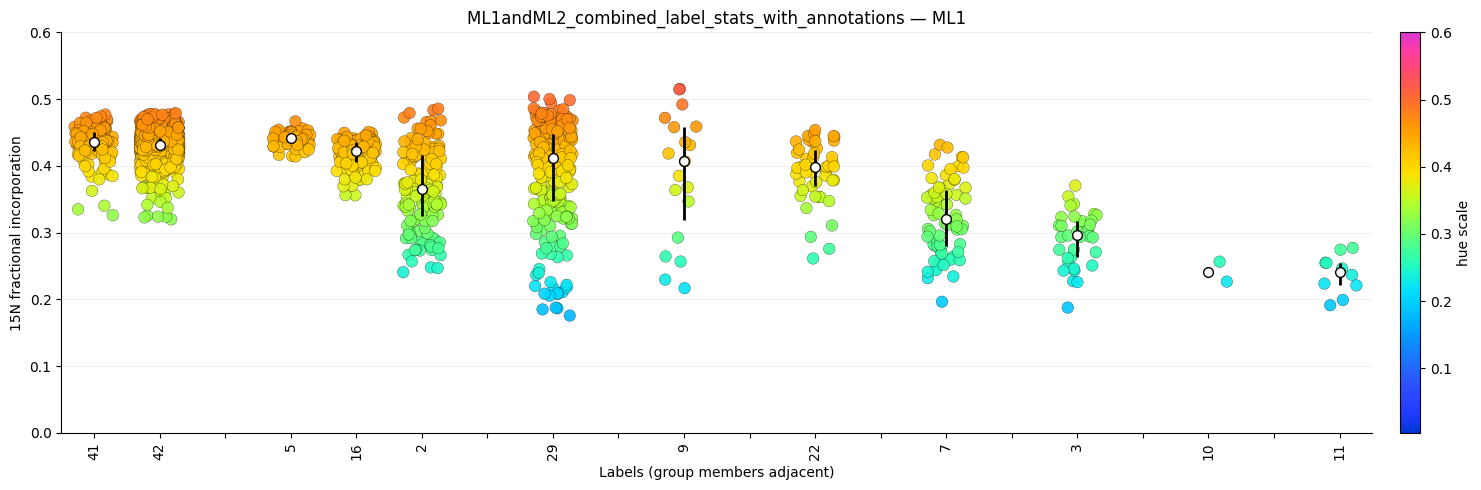

  - Saved ML1andML2_combined_label_stats_with_annotations_ML1_grouped_adjacent.pdf


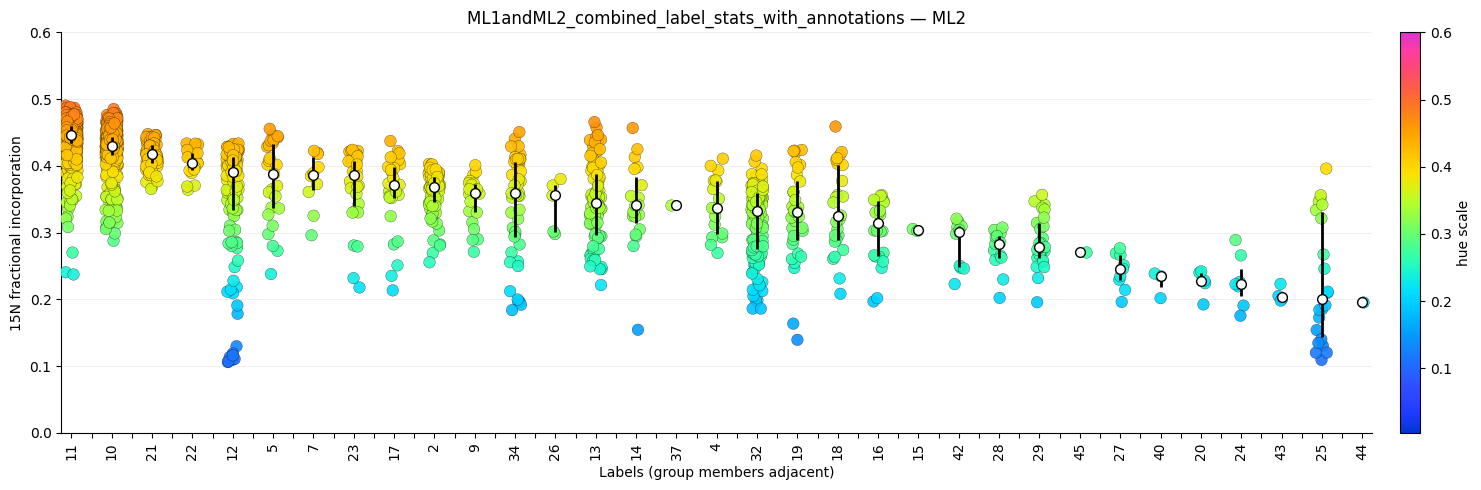

  - Saved ML1andML2_combined_label_stats_with_annotations_ML2_grouped_adjacent.pdf


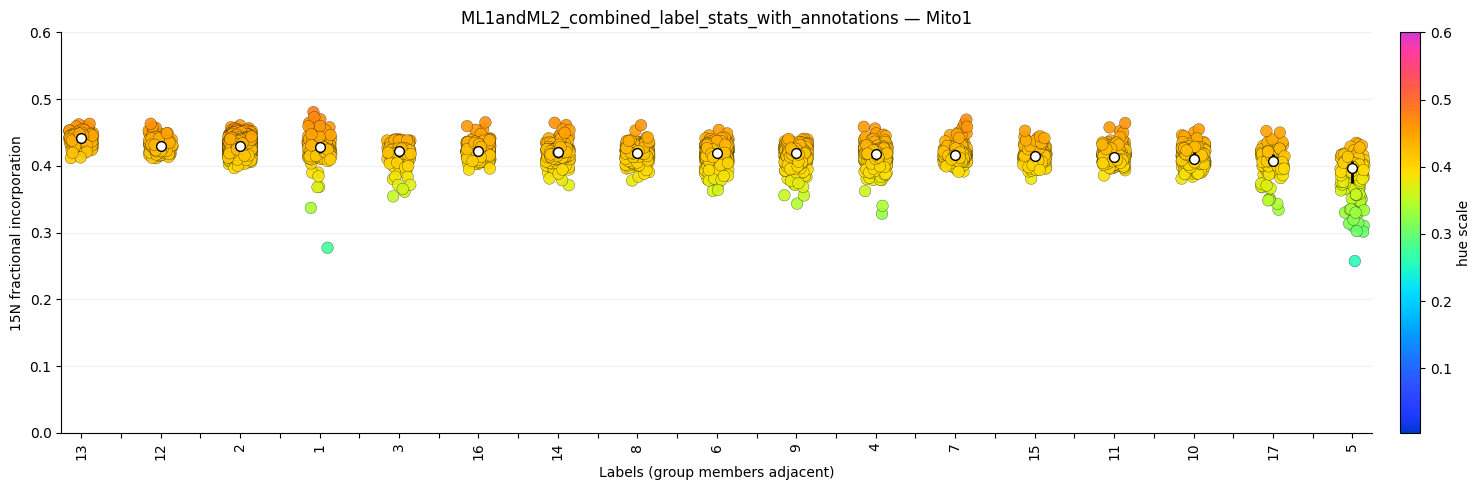

  - Saved ML1andML2_combined_label_stats_with_annotations_Mito1_grouped_adjacent.pdf


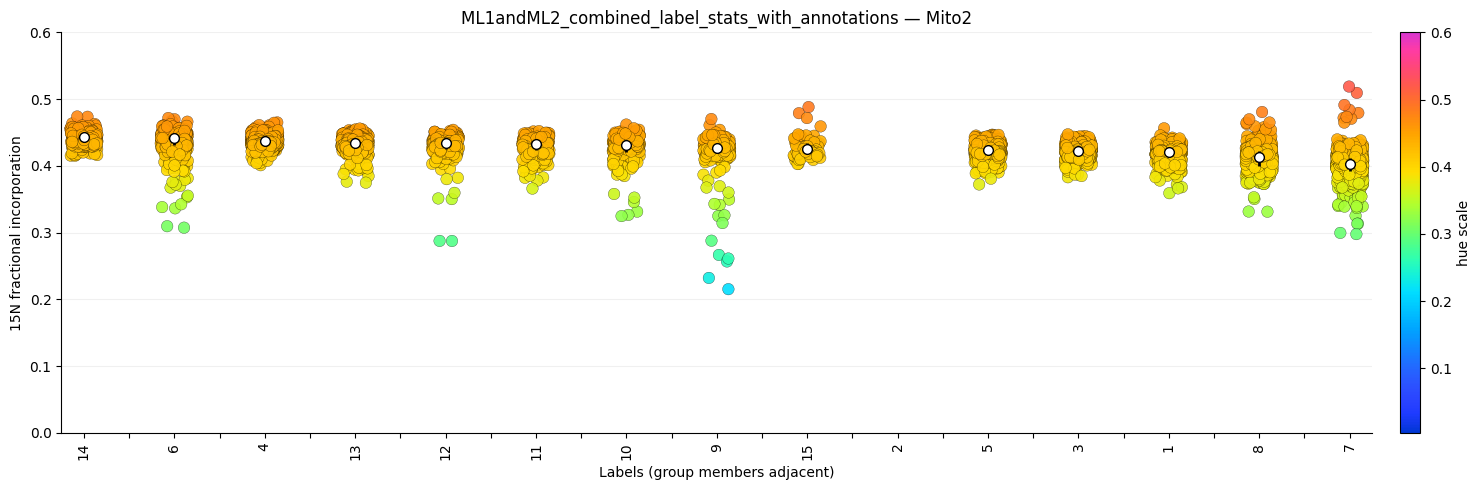

  - Saved ML1andML2_combined_label_stats_with_annotations_Mito2_grouped_adjacent.pdf

Done.


In [27]:
# Jupyter cell — regraph CSV outputs from ./input_regraph
# Generates separate TIFF plots for ML1, ML2, Mito1, and Mito2
# Saved into ./output_regraph (created if needed)
#
# Behavior:
# - Sorts objects by frac_median (descending)
# - Graphs values_fractional on the y-axis
# - Uses Group_IDs to keep grouped labels adjacent
# - Inserts spaces between every group and every singleton
# - Uses the custom LUT.csv colormap if present
# - Uses hue scale 0.0037 to 6.0 for datapoints
# - Exports PDF-friendly TIFFs

from __future__ import annotations

import ast
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize, ListedColormap

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

# ============================================================
# Config
# ============================================================
BASE_DIR = Path(globals().get("SCRIPT_DIR", Path.cwd()))
INPUT_DIR = BASE_DIR / "input_regraph"
OUT_DIR = BASE_DIR / "output_regraph"
OUT_DIR.mkdir(parents=True, exist_ok=True)

ML_TARGETS = ["ML1", "ML2", "Mito1", "Mito2"]

GLOBAL_VMIN = 0.0037
GLOBAL_VMAX = 0.6

EXPORT_DPI = 300
RNG = np.random.default_rng(42)

# Use values_fractional for color so hue matches the plotted y-values
HUE_SOURCE_PRIMARY = "values_fractional"
HUE_SOURCE_FALLBACK = "values_fractional"

# ============================================================
# Sanity checks
# ============================================================
if not INPUT_DIR.exists():
    raise FileNotFoundError(f"Input folder not found: {INPUT_DIR}")

csv_files = sorted(INPUT_DIR.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in: {INPUT_DIR}")

# ============================================================
# LUT loading
# ============================================================
def load_fiji_lut_try(paths=(BASE_DIR / "LUT.csv", INPUT_DIR / "LUT.csv")):
    for p in paths:
        try:
            if not p.exists():
                continue

            df_lut = pd.read_csv(p)
            cols = [c.strip().lower() for c in df_lut.columns]

            if "red" in cols and "green" in cols and "blue" in cols:
                r_idx = cols.index("red")
                g_idx = cols.index("green")
                b_idx = cols.index("blue")
            elif "r" in cols and "g" in cols and "b" in cols:
                r_idx = cols.index("r")
                g_idx = cols.index("g")
                b_idx = cols.index("b")
            else:
                r_idx, g_idx, b_idx = 0, 1, 2

            rgb = df_lut.iloc[:, [r_idx, g_idx, b_idx]].to_numpy(dtype=float) / 255.0
            rgb = np.clip(rgb, 0.0, 1.0)

            cmap = ListedColormap(rgb, name="fiji_lut_from_csv")
            try:
                mpl.colormaps.register(cmap, name="fiji_lut_from_csv", force=True)
            except Exception:
                try:
                    mpl.cm.register_cmap(name="fiji_lut_from_csv", cmap=cmap)
                except Exception:
                    pass

            print(f"Loaded LUT from {p} ({rgb.shape[0]} entries).")
            return cmap

        except Exception as e:
            print(f"Failed to load LUT from {p}: {e}", file=sys.stderr)

    return None

CUSTOM_CMAP = load_fiji_lut_try()
CMAP = CUSTOM_CMAP if CUSTOM_CMAP is not None else cm.get_cmap("viridis")
NORM_FOR_HUE = Normalize(vmin=GLOBAL_VMIN, vmax=GLOBAL_VMAX)

# ============================================================
# Helpers
# ============================================================
def parse_array_cell(cell):
    if cell is None or (isinstance(cell, float) and np.isnan(cell)):
        return np.array([], dtype=float)

    if isinstance(cell, np.ndarray):
        return cell.astype(float, copy=False)

    if isinstance(cell, (list, tuple)):
        try:
            return np.asarray(cell, dtype=float)
        except Exception:
            return np.array([], dtype=float)

    if isinstance(cell, str):
        txt = cell.strip()
        if not txt:
            return np.array([], dtype=float)

        try:
            parsed = ast.literal_eval(txt)
            if isinstance(parsed, (list, tuple, np.ndarray)):
                return np.asarray(parsed, dtype=float)
            return np.asarray([parsed], dtype=float)
        except Exception:
            try:
                parts = [p.strip() for p in txt.strip("[]").split(",") if p.strip()]
                return np.asarray([float(p) for p in parts], dtype=float)
            except Exception:
                return np.array([], dtype=float)

    try:
        return np.asarray([float(cell)], dtype=float)
    except Exception:
        return np.array([], dtype=float)

def parse_group_ids(cell):
    """
    Parse Group_IDs values that may look like:
      "[16, 2, 5]"
      "16,2,5"
      16
    """
    arr = parse_array_cell(cell)
    out = []
    for v in arr:
        try:
            out.append(int(v))
        except Exception:
            pass
    seen = set()
    cleaned = []
    for v in out:
        if v not in seen:
            cleaned.append(v)
            seen.add(v)
    return cleaned

def clean_group_members(members, available_labels):
    seen = set()
    out = []
    for x in members:
        try:
            key = int(x)
        except Exception:
            continue
        if key in available_labels and key not in seen:
            out.append(key)
            seen.add(key)
    return out

def box_colorize(bp, facecolor="white", edgecolor="0.6", alpha=0.18):
    for patch in bp["boxes"]:
        patch.set_facecolor(facecolor)
        patch.set_edgecolor(edgecolor)
        patch.set_alpha(alpha)
        patch.set_linewidth(1.0)
    for med in bp["medians"]:
        med.set_color("black")
        med.set_linewidth(1.2)
        med.set_alpha(0.65)
    for whisk in bp["whiskers"]:
        whisk.set_color("0.45")
        whisk.set_linewidth(1.0)
        whisk.set_alpha(0.55)
    for cap in bp["caps"]:
        cap.set_color("0.45")
        cap.set_linewidth(1.0)
        cap.set_alpha(0.55)

def get_hue_values(row, n):
    vals = parse_array_cell(row.get(HUE_SOURCE_PRIMARY, []))
    if vals.size == 0:
        vals = parse_array_cell(row.get(HUE_SOURCE_FALLBACK, []))
    if vals.size == 0:
        vals = np.full(n, np.nan, dtype=float)
    return vals

def build_blocks(df_ml: pd.DataFrame):
    """
    Build blocks from Group_IDs.

    Sorting:
      - global block sort by frac_median descending
      - within-group member sort by frac_median descending

    Graphing:
      - values_fractional on the y-axis
      - hue values from values_fractional
    """
    required_cols = ["label", "frac_median", "values_fractional"]
    missing = [c for c in required_cols if c not in df_ml.columns]
    if missing:
        raise ValueError(f"Required column(s) missing: {missing}")

    df_ml = df_ml.copy()
    df_ml["label"] = pd.to_numeric(df_ml["label"], errors="coerce")
    df_ml["frac_median"] = pd.to_numeric(df_ml["frac_median"], errors="coerce")
    df_ml = df_ml.dropna(subset=["label", "frac_median"]).copy()
    df_ml["label"] = df_ml["label"].astype(int)

    available_labels = set(df_ml["label"].tolist())
    has_groups = "Group_IDs" in df_ml.columns

    if has_groups:
        df_ml["Group_IDs"] = df_ml["Group_IDs"].astype(str).replace({"nan": "", "None": ""})

    blocks = []

    if has_groups:
        grouped_rows = df_ml[df_ml["Group_IDs"].str.strip().ne("")]
        singleton_rows = df_ml[df_ml["Group_IDs"].str.strip().eq("")]

# -------- grouped blocks --------
        for group_id, gdf in grouped_rows.groupby("Group_IDs", sort=False):
            group_members = clean_group_members(parse_group_ids(group_id), available_labels)
            if not group_members:
                continue

            member_info = []
            for m in group_members:
                row = gdf.loc[gdf["label"].eq(m)]
                if row.empty:
                    continue
                row = row.iloc[0]
                frac_vals = parse_array_cell(row.get("values_fractional", []))
                member_info.append(
                    {
                        "label": int(row["label"]),
                        "frac_median": float(row["frac_median"]),
                        "vals_fractional": frac_vals,
                        "vals_hue": get_hue_values(row, len(frac_vals)),
                    }
                )

            if not member_info:
                continue

            member_info = sorted(member_info, key=lambda x: x["frac_median"], reverse=True)
            block_frac_median = float(np.nanmedian([m["frac_median"] for m in member_info]))

            blocks.append(
                {
                    "name": str(group_id),
                    "is_group": True,
                    "members": member_info,
                    "block_frac_median": block_frac_median,
                }
            )

# -------- singleton blocks --------
        for _, row in singleton_rows.iterrows():
            lab = int(row["label"])
            frac_vals = parse_array_cell(row.get("values_fractional", []))
            blocks.append(
                {
                    "name": str(lab),
                    "is_group": False,
                    "members": [
                        {
                            "label": lab,
                            "frac_median": float(row["frac_median"]),
                            "vals_fractional": frac_vals,
                            "vals_hue": get_hue_values(row, len(frac_vals)),
                        }
                    ],
                    "block_frac_median": float(row["frac_median"]),
                }
            )

    else:
        for _, row in df_ml.iterrows():
            try:
                lab = int(row["label"])
                frac_median = float(row["frac_median"])
            except Exception:
                continue

            frac_vals = parse_array_cell(row.get("values_fractional", []))
            blocks.append(
                {
                    "name": str(lab),
                    "is_group": False,
                    "members": [
                        {
                            "label": lab,
                            "frac_median": frac_median,
                            "vals_fractional": frac_vals,
                            "vals_hue": get_hue_values(row, len(frac_vals)),
                        }
                    ],
                    "block_frac_median": frac_median,
                }
            )

    blocks = sorted(blocks, key=lambda x: x["block_frac_median"], reverse=True)
    return blocks

def flatten_with_spacers(blocks_sorted):
    """
    Members inside the same block are contiguous.
    A spacer is inserted between every block, including between singletons.
    """
    plot_sequence = []
    for bi, block in enumerate(blocks_sorted):
        for member in block["members"]:
            plot_sequence.append(
                {
                    "label": member["label"],
                    "frac_median": member["frac_median"],
                    "vals_fractional": member["vals_fractional"],
                    "vals_hue": member["vals_hue"],
                    "is_group_member": block["is_group"],
                    "is_spacer": False,
                }
            )
        if bi != len(blocks_sorted) - 1:
            plot_sequence.append({"is_spacer": True})
    return plot_sequence

def plot_one_ml(df_csv: pd.DataFrame, csv_path: Path, ml_name: str):
    ml_df = df_csv[df_csv["ML_number"].astype(str).str.strip().eq(ml_name)].copy()
    if ml_df.empty:
        print(f"  - {ml_name}: not present, skipping")
        return

    blocks_sorted = build_blocks(ml_df)
    plot_sequence = flatten_with_spacers(blocks_sorted)

    n_items = len(plot_sequence)
    x_positions = np.arange(n_items)
    x_tick_labels = ["" if itm.get("is_spacer", False) else str(itm["label"]) for itm in plot_sequence]

    fig_w = 15
    fig_h = 5
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    all_y = []

    for xi, itm in zip(x_positions, plot_sequence):
        if itm.get("is_spacer", False):
            continue

        frac_vals = np.asarray(itm["vals_fractional"], dtype=float)
        hue_vals = np.asarray(itm["vals_hue"], dtype=float)

        if frac_vals.size == 0:
            continue

        if hue_vals.size != frac_vals.size:
            hue_vals = np.full(frac_vals.size, float("nan"), dtype=float)

        jitter = (RNG.random(frac_vals.size) - 0.5) * 0.6
        xs = np.full(frac_vals.size, xi) + jitter

        normed = np.clip((hue_vals - GLOBAL_VMIN) / (GLOBAL_VMAX - GLOBAL_VMIN), 0.0, 1.0)
        cols = CMAP(normed)

        ax.scatter(
            xs,
            frac_vals,
            s=70,
            color=cols,
            alpha=0.9,
            edgecolors="k",
            linewidths=0.2,
            zorder=3,
        )

        q25 = np.percentile(frac_vals, 25)
        q75 = np.percentile(frac_vals, 75)
        med = float(np.median(frac_vals))

        ax.plot([xi, xi], [q25, q75], color="k", linewidth=2, solid_capstyle="butt", zorder=4)
        ax.plot([xi], [med], marker="o", markersize=7, markerfacecolor="white",
                markeredgecolor="k", zorder=5)

        all_y.extend([q25, q75, med, float(np.min(frac_vals)), float(np.max(frac_vals))])

    if not all_y:
        print(f"  - {ml_name}: no valid values found, skipping")
        plt.close(fig)
        return

    y_min = 0
    y_max = 0.6

    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_tick_labels, rotation=90)
    ax.set_xlim(-0.5, n_items - 0.5)
    ax.set_ylim(y_min, y_max)

    ax.set_ylabel("15N fractional incorporation")
    ax.set_xlabel("Labels (group members adjacent)")
    ax.set_title(f"{csv_path.stem} — {ml_name}")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.18, zorder=0)

    sm = cm.ScalarMappable(cmap=CMAP, norm=NORM_FOR_HUE)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.02)
    cbar.set_label("hue scale")

    plt.tight_layout()


    # ============================================================
    # Illustrator-friendly PDF export
    # ============================================================
    out_name = f"{csv_path.stem}_{ml_name}_grouped_adjacent.pdf"
    out_path = OUT_DIR / out_name

    fig.savefig(
        out_path,
        format="pdf",
        bbox_inches="tight",
        facecolor="white",
        edgecolor="none",
    )

    plt.show(fig)
    plt.close(fig)

    print(f"  - Saved {out_path.name}")

# ============================================================
# Main
# ============================================================
print(f"Input folder:  {INPUT_DIR}")
print(f"Output folder: {OUT_DIR}")
print(f"CSV files found: {len(csv_files)}")

for csv_path in csv_files:
    print(f"\nProcessing: {csv_path.name}")
    df = pd.read_csv(csv_path)

    required = {"ML_number", "label", "frac_median"}
    missing = sorted(required - set(df.columns))
    if missing:
        print(f"  - Skipping (missing required columns: {missing})")
        continue

    df["ML_number"] = df["ML_number"].astype(str).str.strip()

    if "values_fractional" not in df.columns:
        df["values_fractional"] = ""
    if "values_ratio" not in df.columns:
        df["values_ratio"] = ""
    if "Group_IDs" not in df.columns:
        df["Group_IDs"] = ""

    for ml_name in ML_TARGETS:
        plot_one_ml(df, csv_path, ml_name)

print("\nDone.")